# Bilingual document translation

In this example we show an application of SONAR as a means of aligning translated documents for study or language exploration.
We present the The Hound of the Baskervilles in its English version, alongside the translation to Spanish.

In [16]:
# Config plotly to work in Jupyter Notebook
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'png'
import numpy as np
from tqdm import tqdm as track
import pandas as pd
import torch
from fastdtw import fastdtw
from scipy.spatial.distance import cosine
from sentence_splitter import SentenceSplitter
from sklearn.metrics.pairwise import cosine_similarity

In [17]:
import torch
from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline, EmbeddingToTextModelPipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = torch.device(DEVICE)
torch.set_grad_enabled(False)
print(DEVICE)

cpu


In [4]:
import re
from html.parser import HTMLParser
from urllib.request import Request, urlopen


# Collect every complete <div class="row">, including nested <div> elements.
def extract_divs_by_class(html, class_name):
    div_pattern = re.compile(r"</?div\b[^>]*>", re.IGNORECASE)
    class_pattern = re.compile(
        rf"\bclass\s*=\s*['\"][^'\"]*\b{re.escape(class_name)}\b[^'\"]*['\"]",
        re.IGNORECASE,
    )
    rows = []
    depth = 0
    start = None

    for match in div_pattern.finditer(html):
        tag = match.group()
        if tag.startswith("</"):
            if start is not None:
                depth -= 1
                if depth == 0:
                    rows.append(html[start:match.end()])
                    start = None
        elif start is not None:
            depth += 1
        elif class_pattern.search(tag):
            start = match.start()
            depth = 1

    return rows


class BilingualRowParser(HTMLParser):
    def __init__(self):
        super().__init__(convert_charrefs=True)
        self.text_by_language = {"en": [], "es": []}
        self.current_language = None
        self.column_depth = 0

    def handle_starttag(self, tag, attrs):
        if tag != "div":
            return

        attributes = dict(attrs)
        if attributes.get("lang") in self.text_by_language:
            self.current_language = attributes["lang"]
            self.column_depth = 1
        elif self.current_language is not None:
            self.column_depth += 1

    def handle_endtag(self, tag):
        if tag == "div" and self.current_language is not None:
            self.column_depth -= 1
            if self.column_depth == 0:
                self.current_language = None

    def handle_data(self, data):
        if self.current_language is not None:
            self.text_by_language[self.current_language].append(data)

    def texts(self):
        return {
            language: " ".join("".join(parts).split())
            for language, parts in self.text_by_language.items()
        }

eng_text = ""
spa_text = ""

for chapter in range(1, 16): 

    url = f"http://bilinguis.com/book/baskerville/en/es/c{chapter}/"
    request = Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urlopen(request, timeout=30) as response:
        chapter_html = response.read().decode("utf-8")
    chapter_rows = extract_divs_by_class(chapter_html, "row")
    chapter_pairs = []
    for row in chapter_rows:
        parser = BilingualRowParser()
        parser.feed(row)
        pair = parser.texts()
        if pair["en"] and pair["es"]:
            chapter_pairs.append(pair)

    eng_text += "\n".join(pair["en"] for pair in chapter_pairs)
    spa_text += "\n".join(pair["es"] for pair in chapter_pairs)

eng_splitter = SentenceSplitter(language="en")
spa_splitter = SentenceSplitter(language="es")
eng_sentences = eng_splitter.split(text=eng_text)
spa_sentences = spa_splitter.split(text=spa_text)

In [5]:
text_embedding_pipeline = TextToEmbeddingModelPipeline(
    encoder="text_sonar_basic_encoder",
    tokenizer="text_sonar_basic_encoder",
    device=DEVICE,
 )

embedding_text_pipeline = EmbeddingToTextModelPipeline(
    decoder="text_sonar_basic_decoder",
    tokenizer="text_sonar_basic_decoder",
    device=DEVICE,
)

parameter load: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   628/628 100% 0:00:00

## Similarity of sentences between texts

We may compute the matrix cosine similarity of each of the sentences in the novel extracts, with each of the sentences present in the translations.

In [6]:
eng_embeddings = text_embedding_pipeline.predict(eng_sentences, source_lang="eng_Latn")
spa_embeddings = text_embedding_pipeline.predict(spa_sentences, source_lang="spa_Latn")

eng_spa_cos_sim = cosine_similarity(eng_embeddings, spa_embeddings)

/Users/roicort/GitHub/rEAMember/.venv/lib/python3.12/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:85.)
  return _C._get_float32_matmul_precision()


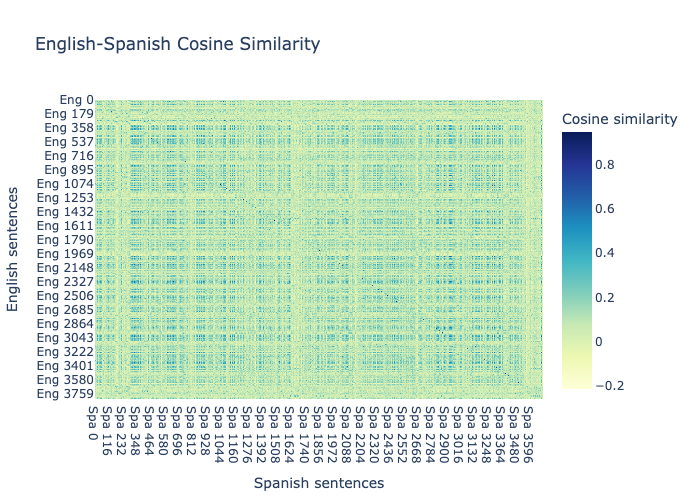

In [24]:
eng_spa_df = pd.DataFrame(
    eng_spa_cos_sim,
    index=[f"Eng {i}" for i in range(len(eng_sentences))],
    columns=[f"Spa {i}" for i in range(len(spa_sentences))],
)


def plot_heatmap(similarity_df, title):
    fig = px.imshow(
        similarity_df,
        color_continuous_scale="YlGnBu",
        labels={"x": "Spanish sentences", "y": "English sentences", "color": "Cosine similarity"},
        title=title,
        aspect="auto",
    )
    fig.update_yaxes(autorange="reversed")
    fig.show()


plot_heatmap(eng_spa_df, "English-Spanish Cosine Similarity")

## Finding aligned sentence pairs

We may find which of the sentences correspond to which in the translation by determining the cosine distance and considering equivalent in meaning those sentences that are the closest together in the embedding space.

`eng_spa_alignment` contains the actual alignment (or mapping) between the indices of (English and Spanish). The 'cosine' distance is used to measure how similar or dissimilar the embeddings are at each point.

`eng_spa_distance` is the total minimal distance between the two sequences of embeddings the two sequences (English and Spanish embeddings), i.e., which English sentence aligns with which Spanish sentence based on the dynamic time warping (DTW) algorithm.


Sentence Pairs Above Threshold 0.7 (English -> Spanish):


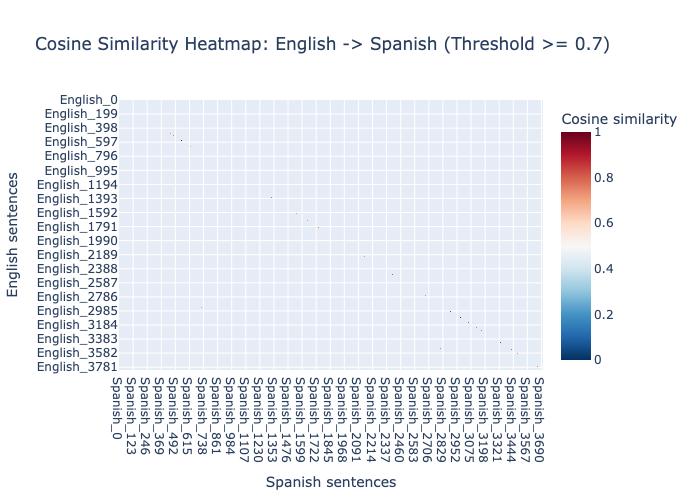

In [25]:
def create_cosine_similarity_heatmap(
    cos_sim_matrix, sent1_list, sent2_list, lang1_name, lang2_name, threshold=0.6
):
    df = pd.DataFrame(
        cos_sim_matrix,
        index=[f"{lang1_name}_{i}" for i in range(len(sent1_list))],
        columns=[f"{lang2_name}_{i}" for i in range(len(sent2_list))],
    )

    print(f"Sentence Pairs Above Threshold {threshold} ({lang1_name} -> {lang2_name}):")
    #for i in range(len(sent1_list)):
    #    for j in range(len(sent2_list)):
            #if df.iat[i, j] >= threshold:
            #    print(
            #        f"{lang1_name} Sentence {i}: {sent1_list[i]} <-> {lang2_name} Sentence {j}: {sent2_list[j]} (Cosine Similarity: {df.iat[i, j]:.2f})"
            #    )

    fig = px.imshow(
        df.where(df >= threshold),
        color_continuous_scale="RdBu_r",
        zmin=0,
        zmax=1,
        labels={"x": f"{lang2_name} sentences", "y": f"{lang1_name} sentences", "color": "Cosine similarity"},
        title=f"Cosine Similarity Heatmap: {lang1_name} -> {lang2_name} (Threshold >= {threshold})",
        aspect="auto",
    )
    fig.update_yaxes(autorange="reversed")
    fig.show()


create_cosine_similarity_heatmap(
    eng_spa_cos_sim, eng_sentences, spa_sentences, "English", "Spanish", threshold=0.7
)

We may encounter special cases where the _translation_ or match between sentences in the embedding space is not 1-to-1. In such instances, a single sentence may exhibit "good enough" similarity with multiple sentences in the other language. Consider the following example:

```
English Sentence 41: "Good God," he thought. <-> Spanish Sentence 12: «Dios mío!», pensó. (Cosine Similarity: 0.82)  
English Sentence 41: "Good God," he thought. <-> Spanish Sentence 30: «¡Dios del cielo!», pensó. (Cosine Similarity: 0.82)  
```

This illustrates that the embedding space captures the implied meaning of sentences rather than relying solely on direct word-for-word translations.


## Creating a Bilingual Book to Read

In this example notebook, one of the applications of the alignment is to create a **bilingual notebook**. This book provides a side-by-side comparison of sentences from different languages. The comparison is made possible by calculating the optimal path through which to traverse the embedding space, considering the cosine similarity at each point. To achieve this efficiently, one can utilize the **FastDTW** algorithm. Note that for this example we are only reconstructing a side-by-side view of the books from what the source of the books provides, but may also be used on texts that where not aligned before.

#### FastDTW

**FastDTW** (Fast Dynamic Time Warping) is an optimized version of Dynamic Time Warping (DTW), a distance measure used to align two sequences of data that may vary in time or length. DTW identifies the optimal alignment by minimizing the distance between the sequences, typically for time series data. It allows for stretching or compressing parts of the sequences to achieve a better match.

A key characteristic of DTW is that it ensures **monotonic alignment**, meaning the sequence of aligned points progresses consistently without reversing. This property is crucial for aligning bilingual texts, where each sentence or phrase in one language should correspond in order with the sentences in another language, preserving the logical sequence.

**Note:** The current alignment implementation does not maintain monotonicity; for example, it may incorrectly match **English Sentence 41 with Spanish Sentence 12**, which disrupts the logical order of the sentences.

FastDTW enhances the speed of computation while approximating the results of traditional DTW, making it more efficient for larger datasets or longer sequences.

For more information on **FastDTW**, see [this](https://cs.fit.edu/~pkc/papers/tdm04.pdf).


In [32]:
def dtw_align(eng_embeddings, spa_embeddings):
    alignments = []

    distance, path = fastdtw(
        eng_embeddings.numpy(), spa_embeddings.numpy(), dist=cosine
    )
    alignments.append(path)

    return alignments


eng_spa_alignments = dtw_align(eng_embeddings, spa_embeddings)

alignment_table = []

for eng_idx, spa_idx in eng_spa_alignments[0]:
    eng_sentence = eng_sentences[eng_idx] if eng_idx < len(eng_sentences) else ""
    spa_sentence = spa_sentences[spa_idx] if spa_idx < len(spa_sentences) else ""

    alignment_table.append((eng_sentence, spa_sentence))

bilingual_df = pd.DataFrame(
    alignment_table, columns=["English Sentence", "Spanish Sentence"]
)
pd.set_option("display.max_colwidth", None)

n = 10

html_table = bilingual_df.loc[:n].to_html(index=False)

from IPython.display import HTML, display

display(HTML(html_table))

English Sentence,Spanish Sentence
It was to your account of a West-Country legend that this tale owes its inception.,"La idea para este relato me laproporcionó mi amigo, el señor Fletcher Robinson, que me ha ayudado además en la línea argumental y en los detalles de ambientación."
For this and for your help in the details all thanks.,"La idea para este relato me laproporcionó mi amigo, el señor Fletcher Robinson, que me ha ayudado además en la línea argumental y en los detalles de ambientación."
"Yours most truly, A. CONAN DOYLE.",Arthur Conan Doyle
Chapter 1,CAPÍTULO UNO
Mr. Sherlock Holmes,EL SEÑOR SHERLOCK HOLMES
"Mr. Sherlock Holmes, who was usually very late in the mornings, save upon those not infrequent occasions when he was up all night, was seated at the breakfast table.","El señor Sherlock Holmes, que de ordinario se levantaba muy tarde, excepto en las ocasiones nada infrecuentes en que no se acostaba en toda la noche, estaba desayunando."
I stood upon the hearth-rug and picked up the stick which our visitor had left behind him the night before.,"Yo, que me hallaba de pie junto a la chimenea, me agaché para recoger el bastón olvidado por nuestro visitante de la noche anterior."
"It was a fine, thick piece of wood, bulbous-headed, of the sort which is known as a ""Penang lawyer.""","Sólido, de madera de buena calidad y con un abultamiento a modo de empuñadura, era del tipo que se conoce como «abogado de Penang»."
Just under the head was a broad silver band nearly an inch across.,"Inmediatamente debajo de la protuberancia el bastón llevaba una ancha tira de plata, de más de dos centímetros, en la que estaba grabado «A James Mortimer, M.R.C.S., de sus amigos de C.C.H.», y el año, « 1884»."
"""To James Mortimer, M.R.C.S., from his friends of the C.C.H.,"" was engraved upon it, with the date ""1884.""","Inmediatamente debajo de la protuberancia el bastón llevaba una ancha tira de plata, de más de dos centímetros, en la que estaba grabado «A James Mortimer, M.R.C.S., de sus amigos de C.C.H.», y el año, « 1884»."


# MAE

## ¿Could we use the EAM to align the texts between English and Spanish? 

This exeriment creates a EAM in which we register only the texts in English.
Then we use the spanish texts as cues for recalling the original english text.

In [18]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "reamember").exists():
    PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from tqdm import tqdm

from reamember.eam.associative import NumpyAssociativeMemory as AssociativeMemory
from reamember.eam.mops import memorize
from reamember.utils import (
    Quant,
)

In [19]:
M = m=pow(2, 4)
print(M)

16


In [20]:
all = torch.cat([eng_embeddings, spa_embeddings], dim=0)

quantizer = Quant(all)

eam = AssociativeMemory(
    n=1024,
    m=M,
    xi=100,
    sigma=0.01,
    iota=0,
    kappa=0,
)
eam = memorize(
    eam,
    dataset=eng_embeddings,
    quantizer=quantizer,
    batch_size=8,
) # Memorizamos solo en inglés

✓ Quantizing features...

[INFO] Memorizing 3821 features with shape (3821, 1024)...


100%|██████████| 478/478 [00:00<00:00, 957.90it/s]


In [ ]:
with torch.no_grad():
    for i, cue in enumerate(spa_embeddings):
        cue_embedding = cue.unsqueeze(0).cpu().numpy()
        cue_quantized = quantizer.quantize(cue_embedding, eam.m)

        recalled_embeddings, recognized, weights = eam.batch_recall(cue_quantized)
        recognized = bool(np.asarray(recognized)[0])
        weight = float(np.asarray(weights, dtype=float)[0])

        if not recognized:
            print(f"Warning: Cue {i} was not recognized.")
        else:
            recalled_embedding = quantizer.dequantize(
                np.asarray(recalled_embeddings, dtype=float), eam.m
            )[0]
            recalled_embedding = torch.as_tensor(
                recalled_embedding, dtype=torch.float32
            ).unsqueeze(0)

            reconstructed_batch = embedding_text_pipeline.predict(recalled_embedding, target_lang="eng_Latn")
            # Print original text - reconstructed text comparison
            reconstructed_text = reconstructed_batch[0]
            print(f"Original text: {spa_sentences[i]}")
            print(f"Reconstructed text: {reconstructed_text}")
            print(f"Recognized: {recognized}")
            print(f"Weight: {weight}")
            print(f"SPA Embedding: {spa_embeddings[i].unsqueeze(0)}")
            print(f"ENG Embedding: {eng_embeddings[i].unsqueeze(0)}")
            print(f"SPA-ENG Cosine Similarity: {cosine_similarity(spa_embeddings[i].unsqueeze(0), eng_embeddings[i].unsqueeze(0))[0]}")
            print(f"CUE-RECALLED Cosine Similarity: {cosine_similarity(cue.unsqueeze(0), recalled_embedding)[0]}")
            print("-" * 100)


In [21]:
eng_alicia = ""
spa_alicia = ""

for chapter in range(1, 13): 

    url = f"http://bilinguis.com/book/alice/en/es/c{chapter}/"
    request = Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urlopen(request, timeout=30) as response:
        chapter_html = response.read().decode("utf-8")
    chapter_rows = extract_divs_by_class(chapter_html, "row")
    chapter_pairs = []
    for row in chapter_rows:
        parser = BilingualRowParser()
        parser.feed(row)
        pair = parser.texts()
        if pair["en"] and pair["es"]:
            chapter_pairs.append(pair)

    eng_alicia += "\n".join(pair["en"] for pair in chapter_pairs)
    spa_alicia += "\n".join(pair["es"] for pair in chapter_pairs)

In [22]:
eng_alicia_sentences = eng_splitter.split(text=eng_alicia)
spa_alicia_sentences = spa_splitter.split(text=spa_alicia)

In [23]:
eng_alicia_embeddings = text_embedding_pipeline.predict(eng_alicia_sentences, source_lang="eng_Latn")
spa_alicia_embeddings = text_embedding_pipeline.predict(spa_alicia_sentences, source_lang="spa_Latn")

In [24]:
all = torch.cat([eng_embeddings, spa_embeddings, eng_alicia_embeddings, spa_alicia_embeddings], dim=0)

quantizer = Quant(all)

eam = AssociativeMemory(
    n=1024,
    m=16,
    xi=0,
    sigma=0.01,
    iota=0,
    kappa=0,
)
eam = memorize(
    eam,
    dataset=torch.cat([eng_embeddings, eng_alicia_embeddings, spa_alicia_embeddings], dim=0),
    quantizer=quantizer,
    batch_size=8,
) # Memorizamos solo en inglés

✓ Quantizing features...

[INFO] Memorizing 6996 features with shape (6996, 1024)...


100%|██████████| 875/875 [00:00<00:00, 911.41it/s] 


In [25]:
from tqdm import tqdm

In [26]:
recall_batch_size = 8
cue_embeddings = spa_embeddings.detach().cpu().numpy()
recalled_batches = []
recognized_batches = []
weight_batches = []

for start in tqdm(range(0, len(cue_embeddings), recall_batch_size)):
    cue_batch = cue_embeddings[start : start + recall_batch_size]
    cue_quantized = quantizer.quantize(cue_batch, eam.m)
    recalled_batch, recognized_batch, weight_batch = eam.batch_recall(cue_quantized)
    recalled_batches.append(recalled_batch)
    recognized_batches.append(recognized_batch)
    weight_batches.append(weight_batch)

recalled_quantized = np.concatenate(recalled_batches, axis=0)
recognized_mask = np.concatenate(recognized_batches, axis=0)
weights = np.concatenate(weight_batches, axis=0)
recognized_mask = np.asarray(recognized_mask, dtype=bool)
weights = np.asarray(weights, dtype=float)
recalled_embeddings = torch.as_tensor(
    quantizer.dequantize(recalled_quantized, eam.m),
    dtype=torch.float32,
    device=spa_embeddings.device,
)
recognized_tensor = torch.as_tensor(
    recognized_mask,
    dtype=torch.bool,
    device=spa_embeddings.device,
)

cue_recalled_similarities = np.full(len(spa_embeddings), np.nan)
cue_recalled_similarities[recognized_mask] = torch.nn.functional.cosine_similarity(
    spa_embeddings[recognized_tensor], recalled_embeddings[recognized_tensor]
).detach().cpu().numpy()

cue_recalled_distance = np.full(len(spa_embeddings), np.nan)
cue_recalled_distance[recognized_mask] = torch.nn.functional.pairwise_distance(
    spa_embeddings[recognized_tensor], recalled_embeddings[recognized_tensor]
).detach().cpu().numpy()

aligned_count = min(len(spa_embeddings), len(eng_embeddings))
spa_eng_similarities = np.full(len(spa_embeddings), np.nan)
spa_eng_similarities[:aligned_count] = torch.nn.functional.cosine_similarity(
    spa_embeddings[:aligned_count], eng_embeddings[:aligned_count]
).detach().cpu().numpy()

spa_eng_distance = np.full(len(spa_embeddings), np.nan)
spa_eng_distance[:aligned_count] = torch.nn.functional.pairwise_distance(
    spa_embeddings[:aligned_count], eng_embeddings[:aligned_count]
).detach().cpu().numpy()

recall_results = pd.DataFrame(
    {
        "recognized": recognized_mask,
        "weight": weights,
        "spa_eng_cosine_similarity": spa_eng_similarities,
        "spa_eng_distance": spa_eng_distance,
        "cue_recalled_cosine_similarity": cue_recalled_similarities,
        "cue_recalled_distance": cue_recalled_distance,
    }
)
recognized = int(recognized_mask.sum())
not_recognized = len(recognized_mask) - recognized

100%|██████████| 463/463 [00:00<00:00, 780.29it/s]


In [27]:
recall_results.mean()

recognized                           0.912797
weight                            1049.126829
spa_eng_cosine_similarity            0.107759
spa_eng_distance                     0.298709
cue_recalled_cosine_similarity       0.986335
cue_recalled_distance                0.035731
dtype: float64

In [28]:
sample_indices = np.flatnonzero(recognized_mask)[:25]
if len(sample_indices):
    reconstructed_texts = embedding_text_pipeline.predict(
        recalled_embeddings[sample_indices], target_lang="eng_Latn"
    )
    recall_examples = pd.DataFrame(
        {
            "Texto en español": [spa_sentences[index] for index in sample_indices],
            "Texto reconstruido en inglés": reconstructed_texts,
        },
        index=sample_indices,
    )
    display(recall_examples)
else:
    print("No recognized cues to reconstruct.")

,Texto en español,Texto reconstruido en inglés
1,Arthur Conan Doyle,♪ ♪ ♪ ♪ ♪ ♪ ♪ ♪ ♪ ♪
2,CAPÍTULO UNO,Chapter one
3,EL SEÑOR SHERLOCK HOLMES,This is Mr. Sherlock Holmes.
4,"El señor Sherlock Holmes, que de ordinario se ...","Mr. Sherlock Holmes, who usually got up very l..."
5,"Yo, que me hallaba de pie junto a la chimenea,...","I, who was standing by the fireplace, bent dow..."
8,Era exactamente la clase de bastón que solían ...,It was exactly the kind of stick that the medi...
9,"-Veamos, Watson, ¿a qué conclusiones llega?","- Let's see, Watson, what conclusions do you d..."
10,-¿Cómo sabe lo que estoy haciendo?,- How do you know what I'm doing?
11,Voy a creer que tiene usted ojos en el cogote.,I'm going to believe you have eyes on the hood.
13,"Vamos, Watson, dígame qué opina del bastón de ...","Come on, Watson, tell me what you think of our..."


In [41]:
sample_indices = np.flatnonzero(recognized_mask)[:25]
dtw_english_by_spanish = {}
for eng_index, spa_index in eng_spa_alignments[0]:
    dtw_english_by_spanish.setdefault(spa_index, []).append(eng_index)

In [42]:
if len(sample_indices):
    reconstructed_texts = embedding_text_pipeline.predict(
        recalled_embeddings[sample_indices], target_lang="eng_Latn"
    )
    recall_dtw_comparison = pd.DataFrame(
        {
            "Índice español": sample_indices,
            "Pista en español": [spa_sentences[index] for index in sample_indices],
            "Inglés reconstruido por EAM": reconstructed_texts,
            "Alineación por DTW": [
                " | ".join(eng_sentences[eng_index] for eng_index in dtw_english_by_spanish[index])
                for index in sample_indices
            ],
        }
    )
    display(recall_dtw_comparison)
else:
    print("No recognized cues to reconstruct.")

,Índice español,Pista en español,Inglés reconstruido por EAM,Alineación por DTW
0,1,Arthur Conan Doyle,♪ ♪ ♪ ♪ ♪ ♪ ♪ ♪ ♪ ♪,"Yours most truly, A. CONAN DOYLE."
1,2,CAPÍTULO UNO,Chapter one,Chapter 1
2,3,EL SEÑOR SHERLOCK HOLMES,This is Mr. Sherlock Holmes.,Mr. Sherlock Holmes
3,4,"El señor Sherlock Holmes, que de ordinario se levantaba muy tarde, excepto en las ocasiones nada infrecuentes en que no se acostaba en toda la noche, estaba desayunando.","Mr. Sherlock Holmes, who usually got up very late, except on very rare occasions when he didn't go to bed all night, was having breakfast.","Mr. Sherlock Holmes, who was usually very late in the mornings, save upon those not infrequent occasions when he was up all night, was seated at the breakfast table."
4,5,"Yo, que me hallaba de pie junto a la chimenea, me agaché para recoger el bastón olvidado por nuestro visitante de la noche anterior.","I, who was standing by the fireplace, bent down to pick up the stick that our visitor from the previous night had forgotten.",I stood upon the hearth-rug and picked up the stick which our visitor had left behind him the night before.
5,8,"Era exactamente la clase de bastón que solían llevar los médicos de cabecera a la antigua usanza: digno, sólido y que inspiraba confianza.","It was exactly the kind of stick that the medical staff used to wear in the old way: dignified, solid, and inspired confidence.","It was just such a stick as the old-fashioned family practitioner used to carry--dignified, solid, and reassuring."
6,9,"-Veamos, Watson, ¿a qué conclusiones llega?","- Let's see, Watson, what conclusions do you draw?","""Well, Watson, what do you make of it?"""
7,10,-¿Cómo sabe lo que estoy haciendo?,- How do you know what I'm doing?,"""How did you know what I was doing?"
8,11,Voy a creer que tiene usted ojos en el cogote.,I'm going to believe you have eyes on the hood.,"I believe you have eyes in the back of your head."""
9,13,"Vamos, Watson, dígame qué opina del bastón de nuestro visitante.","Come on, Watson, tell me what you think of our visitor's staff.","""But, tell me, Watson, what do you make of our visitor's stick?"
